This code evaluates the parameter landscape of the Ralph et al. linear optical CNOT gate by performing a 2D parameter sweep over the outer beam splitter angles ($\theta_L$) and central beam splitter angles ($\theta_H$) using the Strawberry Fields Fock backend. Rather than choosing a "best" configuration based strictly on total success probability, which can falsely favor classical routing states, the code selects the optimal configuration on the basis of Conditional Logical Fidelity. 

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\strawberryfields\program.py:732: UserWarning: The circuit consists of 2 disconnected components.
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\strawberryfields\program.py:732: UserWarning: The circuit consists of 2 disconnected components.




Theoretical Evaluation  (theta = 0.9553 rad)


Input |00> -> Success Prob: 0.111111 | Coincidence Prob: 0.111111 | Fidelity: 100.0%
Input |01> -> Success Prob: 0.111111 | Coincidence Prob: 0.111111 | Fidelity: 100.0%
Input |10> -> Success Prob: 0.111111 | Coincidence Prob: 0.111111 | Fidelity: 100.0%
Input |11> -> Success Prob: 0.111111 | Coincidence Prob: 0.111111 | Fidelity: 100.0%


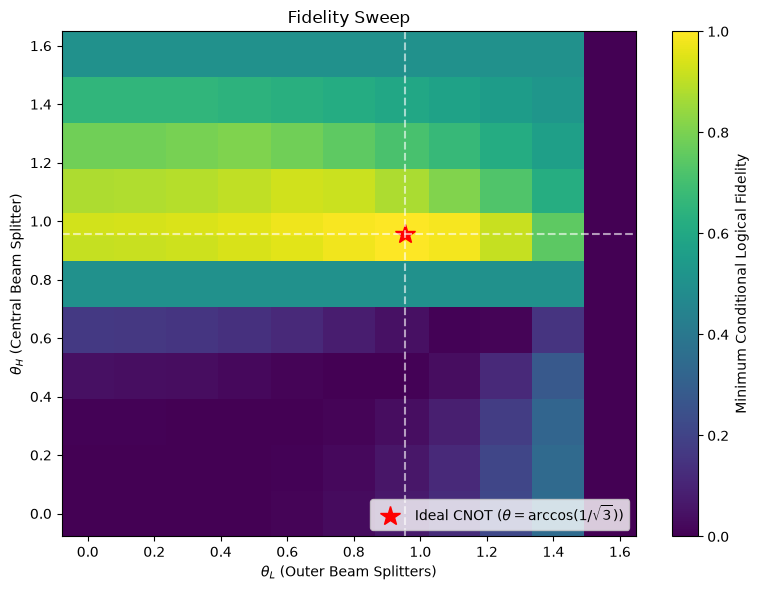

In [1]:
import numpy as np
import strawberryfields as sf
from strawberryfields.ops import Fock, BSgate
import matplotlib.pyplot as plt



def ralph_cnot(input_state, theta_L, theta_H, cutoff_dim=3):
    THETA_PI4 = np.pi/4
    prog = sf.Program(6)
    
    with prog.context as q:    
        for mode, photons in enumerate(input_state):
            if photons > 0:
                Fock(photons) | q[mode]
                
       
        BSgate(theta_L, 0.0)    | (q[0], q[1])  
        BSgate(THETA_PI4, 0.0)  | (q[3], q[4])  
        BSgate(theta_H, 0.0)    | (q[2], q[3])  
        BSgate(theta_L, 0.0)    | (q[4], q[5])  
        BSgate(THETA_PI4, np.pi)| (q[3], q[4])  

    eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff_dim})
    return eng.run(prog)

input_states = {
    "|00>": [0, 1, 0, 1, 0, 0],
    "|01>": [0, 1, 0, 0, 1, 0],
    "|10>": [0, 0, 1, 1, 0, 0],
    "|11>": [0, 0, 1, 0, 1, 0]
}

target_outputs = {
    "|00>": (0, 1, 0, 1, 0, 0),
    "|01>": (0, 1, 0, 0, 1, 0),
    "|10>": (0, 0, 1, 0, 1, 0),
    "|11>": (0, 0, 1, 1, 0, 0)
}

coincidence_states = [
    (0, 1, 0, 1, 0, 0),  # |00>
    (0, 1, 0, 0, 1, 0),  # |01>
    (0, 0, 1, 1, 0, 0),  # |10>
    (0, 0, 1, 0, 1, 0)   # |11>
]


theta_1_3 = np.arccos(1 / np.sqrt(3))  # Theoretical 

# Define grid including the exact T = 1/3 point
grid_points = 11
theta_vals = np.sort(np.unique(np.concatenate([np.linspace(0, np.pi/2, grid_points), [theta_1_3]])))

fidelity_grid = np.zeros((len(theta_vals), len(theta_vals)))
prob_grid = np.zeros((len(theta_vals), len(theta_vals)))


for j, t_H in enumerate(theta_vals):
    for i, t_L in enumerate(theta_vals):
        
        fidelities = []
        succ_probs = []
        
        for name, input_state in input_states.items():
            res = ralph_cnot(input_state, t_L, t_H)
            probs = res.state.all_fock_probs()
            
            p_correct = probs[target_outputs[name]]
            
            # Sum of probabilities across all valid post-selected states
            p_total_coincidence = sum(probs[st] for st in coincidence_states)
            
            # Conditional Logical Fidelity
            if(p_total_coincidence > 1e-12):
                fidelity = p_correct / p_total_coincidence
            else:
                fidelity = 0.0

            fidelities.append(fidelity)
            succ_probs.append(p_correct)
            
        # Store minimum logical fidelity and average success probability across the 4 basis inputs
        fidelity_grid[j, i] = np.min(fidelities)
        prob_grid[j, i] = np.mean(succ_probs)


# Verify at theoretical point

print("\n")
print(f"Theoretical Evaluation  (theta = {theta_1_3:.4f} rad)")
print("\n")
for name, input_state in input_states.items():
    res = ralph_cnot(input_state, theta_1_3, theta_1_3)
    probs = res.state.all_fock_probs()
    p_correct = probs[target_outputs[name]]
    p_coincidence = sum(probs[st] for st in coincidence_states)
    fid = p_correct / p_coincidence
    print(f"Input {name} -> Success Prob: {p_correct:.6f} | Coincidence Prob: {p_coincidence:.6f} | Fidelity: {fid*100:.1f}%")


plt.figure(figsize=(8, 6))
mesh_x, mesh_y = np.meshgrid(theta_vals, theta_vals)

plt.pcolormesh(mesh_x, mesh_y, fidelity_grid, cmap="viridis", shading="auto", vmin=0, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Minimum Conditional Logical Fidelity")

plt.plot(theta_1_3, theta_1_3, 'r*', markersize=15, label=r"Ideal CNOT ($\theta = \arccos(1/\sqrt{3})$)")
plt.axvline(theta_1_3, color='white', linestyle='--', alpha=0.6)
plt.axhline(theta_1_3, color='white', linestyle='--', alpha=0.6)

plt.xlabel(r"$\theta_L$ (Outer Beam Splitters)")
plt.ylabel(r"$\theta_H$ (Central Beam Splitter)")
plt.title("Fidelity Sweep")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The Fidelity Sweep heatmap illustrates how variations in beam splitter angles ($\theta_L$ for outer beam splitters and $\theta_H$ for central beam splitters) affect the minimum conditional logical fidelity of the CNOT gate. The color spectrum measures gate performance from dark purple ($0.0$, failure) to bright yellow ($1.0$, ideal operation). The red star marks the theoretical spot at $\theta = \arccos(1/\sqrt{3})$, which sits centrally in the maximum-fidelity region to confirm optimal gate operation.